In [3]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path =r"H:\Python\3° Etapa\aula4\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"

df = pd.read_excel(path, header=2)

df.head()

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


In [5]:
col_2010 = "População 2010 (Alterações de Limites até 2022)1"
col_2022 = "População Censo 2022"

pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado.head()

,COD. UF,UF,populacao_2010,populacao_2022
0,11.0,RO,1562409.0,1581196.0
1,12.0,AC,733559.0,830018.0
2,13.0,AM,3483985.0,3941613.0
3,14.0,RR,450479.0,636707.0
4,15.0,PA,7581051.0,8120131.0


In [6]:
pop_estado["crescimento_absoluto"] = (
    pop_estado["populacao_2022"] -
    pop_estado["populacao_2010"]
)

pop_estado = pop_estado.sort_values(
    by="crescimento_absoluto",
    ascending=False
)

pop_estado

,COD. UF,UF,populacao_2010,populacao_2022,crescimento_absoluto
19,35.0,SP,41262199.0,44411238.0,3149039.0
21,42.0,SC,6248436.0,7610361.0,1361925.0
25,52.0,GO,6001789.0,7056495.0,1054706.0
20,41.0,PR,10444526.0,11444380.0,999854.0
16,31.0,MG,19597330.0,20539989.0,942659.0
24,51.0,MT,3035122.0,3658649.0,623527.0
4,15.0,PA,7581051.0,8120131.0,539080.0
2,13.0,AM,3483985.0,3941613.0,457628.0
9,23.0,CE,8451644.0,8794957.0,343313.0
17,32.0,ES,3514952.0,3833712.0,318760.0


In [7]:
pop_estado.to_csv(
    r"populacao_por_estado.csv",
    sep=";",
    index=False
)

In [8]:
pop_municipio = df[
    [
        "COD. UF",
        "UF",
        "COD. MUNIC",
        "NOME DO MUNICÍPIO",
        col_2010,
        col_2022
    ]
].copy()

pop_municipio.columns = [
    "COD. UF",
    "UF",
    "COD. MUNIC",
    "MUNICIPIO",
    "populacao_2010",
    "populacao_2022"
]

pop_municipio.head()

,COD. UF,UF,COD. MUNIC,MUNICIPIO,populacao_2010,populacao_2022
0,11.0,RO,15.0,Alta Floresta D'Oeste,24392.0,21494.0
1,11.0,RO,23.0,Ariquemes,90353.0,96833.0
2,11.0,RO,31.0,Cabixi,6313.0,5351.0
3,11.0,RO,49.0,Cacoal,78574.0,86887.0
4,11.0,RO,56.0,Cerejeiras,17029.0,15890.0


In [9]:
pop_municipio["crescimento_absoluto"] = (
    pop_municipio["populacao_2022"] -
    pop_municipio["populacao_2010"]
)

pop_municipio = pop_municipio.sort_values(
    by="crescimento_absoluto",
    ascending=False
)

pop_municipio

,COD. UF,UF,COD. MUNIC,MUNICIPIO,populacao_2010,populacao_2022,crescimento_absoluto
111,13.0,AM,2603.0,Manaus,1802014.0,2063689.0,261675.0
5569,53.0,DF,108.0,Brasília,2572159.0,2817381.0,245222.0
3829,35.0,SP,50308.0,São Paulo,11253503.0,11451999.0,198496.0
3848,35.0,SP,52205.0,Sorocaba,586816.0,723682.0,136866.0
5417,52.0,GO,8707.0,Goiânia,1301912.0,1437366.0,135454.0
...,...,...,...,...,...,...,...
2162,29.0,BA,27408.0,Salvador,2675656.0,2417678.0,-257978.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN


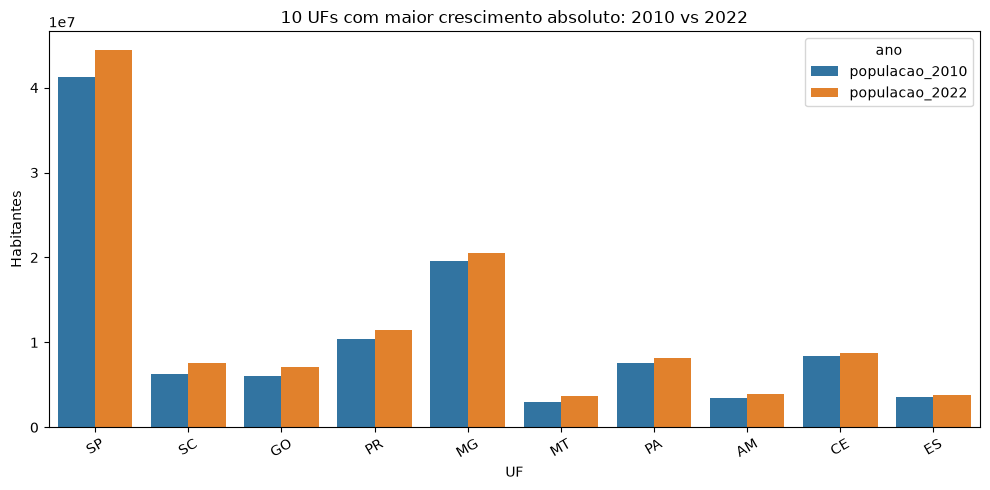

In [10]:
top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=[
        "populacao_2010",
        "populacao_2022"
    ],
    var_name="ano",
    value_name="populacao"
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=top,
    x="UF",
    y="populacao",
    hue="ano",
    ax=ax
)

ax.set_title(
    "10 UFs com maior crescimento absoluto: 2010 vs 2022"
)

ax.set_ylabel("Habitantes")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()